# Logistic Regression model
multi class logistic regression classifier

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,classification_report,ConfusionMatrixDisplay)

import joblib
from sklearn.dummy import DummyClassifier

In [2]:
#obtain locations of data files
directory = Path.cwd()
metadataPath = Path.cwd() / "metadata.csv"
files = [directory / "Healthy", directory / "Crowned", directory /"Root Canal"]
#check if files exist
for path in [metadataPath] + files:
    print(path.name, path.exists())

metadata.csv True
Healthy True
Crowned True
Root Canal True


In [3]:
metadata = pd.read_csv(metadataPath)

print("metadata size:", metadata.shape)
display(metadata.head())

metadata size: (5300, 8)


,patient_id,age,gender,hospital_id,filename,image_path,class_label,date_taken
0,P-8a280791,21,Female,HOSP1,RTC(888).png,Root Canal/RTC(888).png,Root Canal,27-01-22
1,P-8a280791,21,Female,HOSP1,Crowned(135).png,Crowned/Crowned(135).png,Crowned,30-08-24
2,P-21d7e0c2,51,Female,HOSP1,Caries(459).png,Caries/Caries(459).png,Caries,26-01-23
3,P-21d7e0c2,51,Female,HOSP1,RTC(1023).png,Root Canal/RTC(1023).png,Root Canal,4/7/2024
4,P-21d7e0c2,51,Female,HOSP1,RTC(608).png,Root Canal/RTC(608).png,Root Canal,29-08-24


In [4]:
#print class counts
print(metadata["class_label"].value_counts())

class_label
Root Canal    2431
Healthy       1486
Crowned        779
Caries         604
Name: count, dtype: int64


In [5]:
classesBeingUsed = ["Healthy", "Crowned", "Root Canal"]

#drop caries class
df = metadata[metadata["class_label"].isin(classesBeingUsed)].copy()
df = df.reset_index(drop=True)

#print class counts
df["fullPath"] = df["image_path"].apply(lambda x: directory / x)
print("Number of images used:", len(df))
print("Number of unique patients:", df["patient_id"].nunique())
print(df["class_label"].value_counts())

Number of images used: 4696
Number of unique patients: 3050
class_label
Root Canal    2431
Healthy       1486
Crowned        779
Name: count, dtype: int64


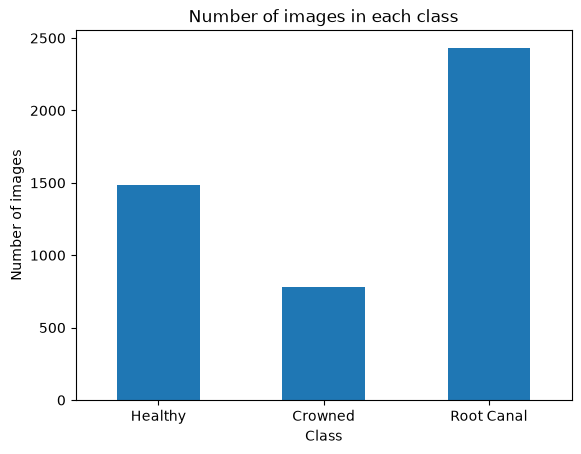

In [6]:
#show class  counts in a graph
df["class_label"].value_counts().reindex(classesBeingUsed).plot(kind="bar")
plt.title("Number of images in each class")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=0)
plt.show()

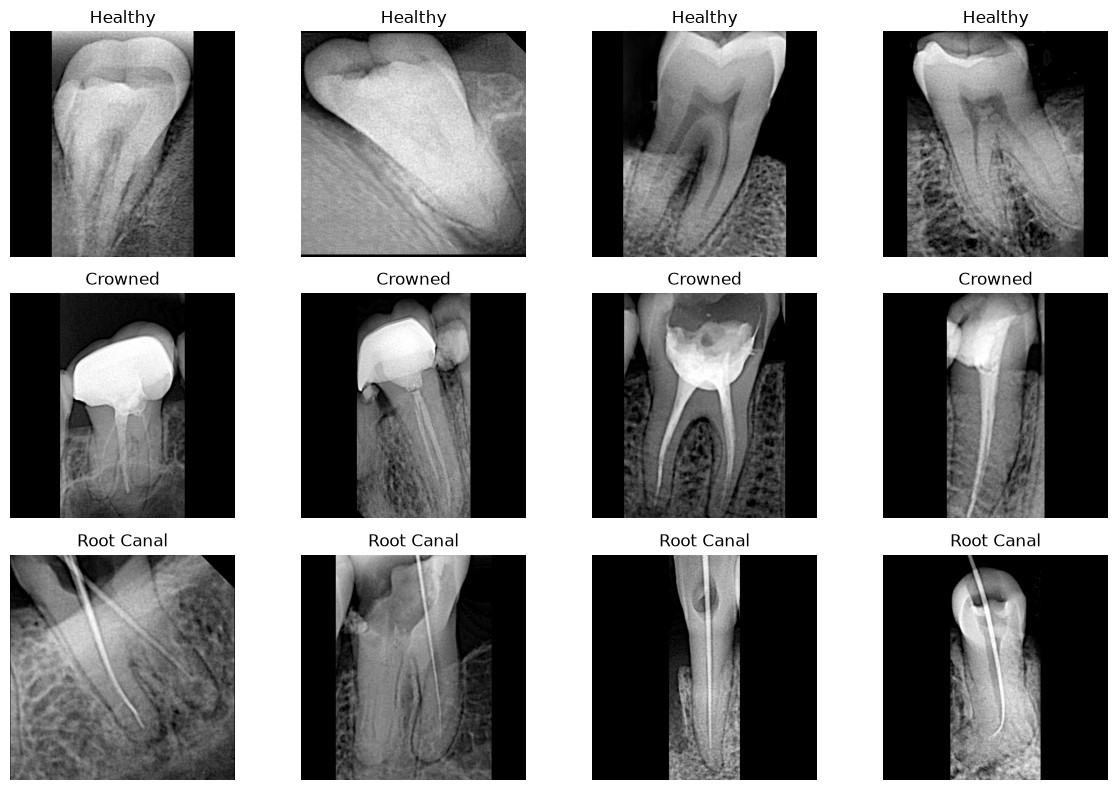

In [7]:
#show example x-rays for each of the classes
plt.figure(figsize=(12, 8))
count = 1
for class_name in classesBeingUsed:
    examples = df[df["class_label"] == class_name].sample(4, random_state=42)

    for i, row in examples.iterrows():
        image = Image.open(row["fullPath"]).convert("L")

        plt.subplot(3, 4, count)
        plt.imshow(image, cmap="gray")
        plt.title(class_name)
        plt.axis("off")

        count += 1

plt.tight_layout()
plt.show()

In [8]:
image_size = 32
def preprocess_image(image_path, image_size=image_size):
    image = Image.open(image_path).convert("L")
    image_array = np.array(image)

    # crop black region around each image
    mask = image_array > 5
    if mask.any():
        rows, cols = np.where(mask)
        image_array = image_array[rows.min():rows.max() + 1,
        cols.min():cols.max() + 1]

    #make numpy to a PIL image and then resize
    image = Image.fromarray(image_array)
    image = image.resize((image_size, image_size), Image.Resampling.LANCZOS)

    #convert to numbers between 0 and 1
    image_array = np.array(image, dtype=np.float32) / 255.0

    return image_array

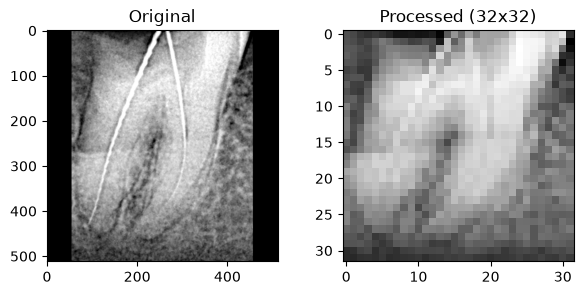

In [9]:
#shgw exapmle of preprocessed image
example_path = df.iloc[0]["fullPath"]

original = Image.open(example_path).convert("L")
processed = preprocess_image(example_path)

plt.figure(figsize=(7, 3))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap="gray")
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(processed, cmap="gray")
plt.title(f"Processed ({image_size}x{image_size})")

plt.show()

In [10]:
X_images = []

for image_path in df["fullPath"]:
    X_images.append(preprocess_image(image_path))

X_images = np.array(X_images)

#flatten each image
X = X_images.reshape(len(X_images), -1)

#keep class labels
y = df["class_label"].to_numpy()

#keep patient ids
groups = df["patient_id"].to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

X shape: (4696, 1024)
y shape: (4696,)
groups shape: (4696,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [11]:
#split1 = 70% training and 30% temp
split_1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_index, temp_index = next(split_1.split(X, y, groups=groups))

X_train = X[train_index]
y_train = y[train_index]
groups_train = groups[train_index]

X_temp = X[temp_index]
y_temp = y[temp_index]
groups_temp = groups[temp_index]

#split2 =  30% of temp into 15% validation and 15% test sets
split_2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

valid_relative_index, test_relative_index = next(
    split_2.split(X_temp, y_temp, groups=groups_temp)
)

X_valid = X_temp[valid_relative_index]
y_valid = y_temp[valid_relative_index]
groups_valid = groups_temp[valid_relative_index]

X_test = X_temp[test_relative_index]
y_test = y_temp[test_relative_index]
groups_test = groups_temp[test_relative_index]

print("Training images:", len(X_train))
print("Validation images:", len(X_valid))
print("Test images:", len(X_test))

Training images: 3296
Validation images: 697
Test images: 703


In [12]:
#find proportion of each class in each set
def show_class_proportions(name, labels):
    counts = pd.Series(labels).value_counts()
    proportions = pd.Series(labels).value_counts(normalize=True)

    result = pd.DataFrame({
        "count": counts,
        "proportion": proportions
    })

    print(f"\n{name}")
    display(result)

show_class_proportions("Training set", y_train)
show_class_proportions("Validation set", y_valid)
show_class_proportions("Test set", y_test)


Training set


,count,proportion
Root Canal,1718,0.521238
Healthy,1061,0.321905
Crowned,517,0.156857



Validation set


,count,proportion
Root Canal,356,0.510760
Healthy,210,0.301291
Crowned,131,0.187948



Test set


,count,proportion
Root Canal,357,0.507824
Healthy,215,0.305832
Crowned,131,0.186344


In [13]:
#create logistic regression model
logistic_model = Pipeline([("pca", PCA(n_components=30,
                whiten=True,svd_solver="randomized",random_state=42)),
    ("logistic_regression",
     LogisticRegression(max_iter=1500,class_weight="balanced",
            solver="lbfgs", random_state=42))])
#train logistic regression model
logistic_model.fit(X_train, y_train)

train_pred = logistic_model.predict(X_train)
valid_pred = logistic_model.predict(X_valid)

print("Training accuracy:", accuracy_score(y_train, train_pred))
print("Validation accuracy:", accuracy_score(y_valid, valid_pred))
print("Validation balanced accuracy:", balanced_accuracy_score(y_valid, valid_pred))
print("Validation macro F1:", f1_score(y_valid, valid_pred, average="macro"))
print("PCA variance retained:", logistic_model.named_steps["pca"].explained_variance_ratio_.sum())

Training accuracy: 0.7090412621359223
Validation accuracy: 0.6944045911047346
Validation balanced accuracy: 0.713486821952385
Validation macro F1: 0.691987498622615
PCA variance retained: 0.87397844


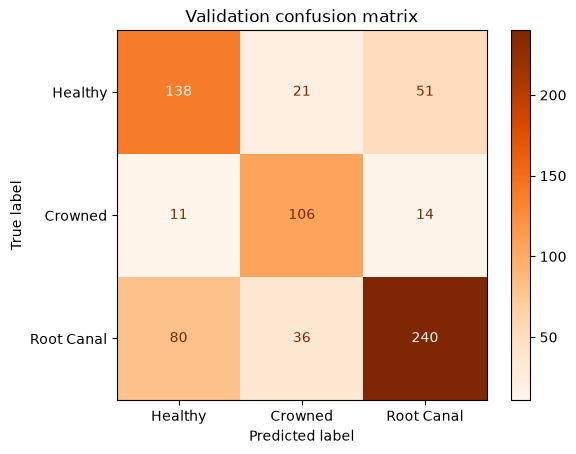

              precision    recall  f1-score   support

     Healthy      0.603     0.657     0.629       210
     Crowned      0.650     0.809     0.721       131
  Root Canal      0.787     0.674     0.726       356

    accuracy                          0.694       697
   macro avg      0.680     0.713     0.692       697
weighted avg      0.706     0.694     0.696       697



In [14]:
#show confusion matrix and report for validation
ConfusionMatrixDisplay.from_predictions(y_valid, valid_pred, labels=classesBeingUsed,cmap = "Oranges")
plt.title("Validation confusion matrix")
plt.show()
print(classification_report(y_valid, valid_pred, labels=classesBeingUsed, digits=3))

In [15]:
#test different number of PCA values
component_values = [10, 20, 30, 50, 75, 100]

results = []

for n_components in component_values:

    model = Pipeline([
        ("pca",
            PCA(n_components=n_components,whiten=True,svd_solver="randomized",random_state=42)),
        ("logistic_regression",
            LogisticRegression(max_iter=1500,class_weight="balanced",solver="lbfgs",random_state=42))])

    model.fit(X_train, y_train)
    prediction = model.predict(X_valid)

    results.append({
        "PCA components": n_components,
        "Validation accuracy": accuracy_score(y_valid, prediction),
        "Balanced accuracy": balanced_accuracy_score(y_valid, prediction),
        "Macro F1": f1_score(y_valid, prediction, average="macro")})

results_df = pd.DataFrame(results)
display(results_df)

,PCA components,Validation accuracy,Balanced accuracy,Macro F1
0,10,0.654232,0.665290,0.646808
1,20,0.651363,0.670540,0.649084
2,30,0.694405,0.713487,0.691987
3,50,0.681492,0.703758,0.682859
4,75,0.682927,0.702435,0.684719
5,100,0.678623,0.699626,0.676793


In [16]:
#chose the best nubmer of PCA components based on the macro f1 score
best_components = int(results_df.loc[results_df["Macro F1"].idxmax(), "PCA components"])

print("Best number of PCA components:", best_components)

Best number of PCA components: 30


In [17]:
#train the final model using both the training and valid datasets
#to then be tested against the final tesing dataset
X_train_final = np.concatenate([X_train, X_valid])
y_train_final = np.concatenate([y_train, y_valid])

final_model = Pipeline([
    ("pca",
        PCA(n_components=best_components,whiten=True,svd_solver="randomized",random_state=42)),
    ("logistic_regression",
    LogisticRegression(max_iter=1500,class_weight="balanced",solver="lbfgs",random_state=42))])

final_model.fit(X_train_final, y_train_final)

test_pred = final_model.predict(X_test)

print("FINAL TEST ACCURACY:",accuracy_score(y_test, test_pred))

print("FINAL TEST BALANCED ACCURACY:", balanced_accuracy_score(y_test, test_pred))

print("FINAL TEST MACRO F1:",f1_score(y_test, test_pred, average="macro"))

FINAL TEST ACCURACY: 0.7098150782361309
FINAL TEST BALANCED ACCURACY: 0.7164206590382173
FINAL TEST MACRO F1: 0.7023373163511567


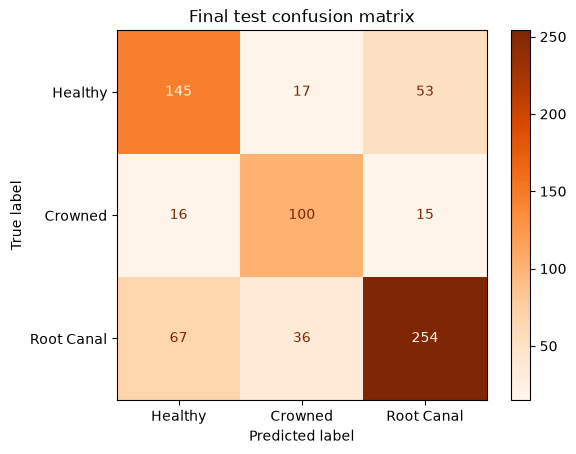

              precision    recall  f1-score   support

     Healthy      0.636     0.674     0.655       215
     Crowned      0.654     0.763     0.704       131
  Root Canal      0.789     0.711     0.748       357

    accuracy                          0.710       703
   macro avg      0.693     0.716     0.702       703
weighted avg      0.717     0.710     0.711       703



In [18]:
#again show confusion matrix and report but for whole training set against test set
ConfusionMatrixDisplay.from_predictions(y_test,test_pred,labels=classesBeingUsed,cmap="Oranges")

plt.title("Final test confusion matrix")
plt.show()

print(classification_report(y_test,test_pred,labels=classesBeingUsed,digits=3))

num of images incorrectly classified: 204


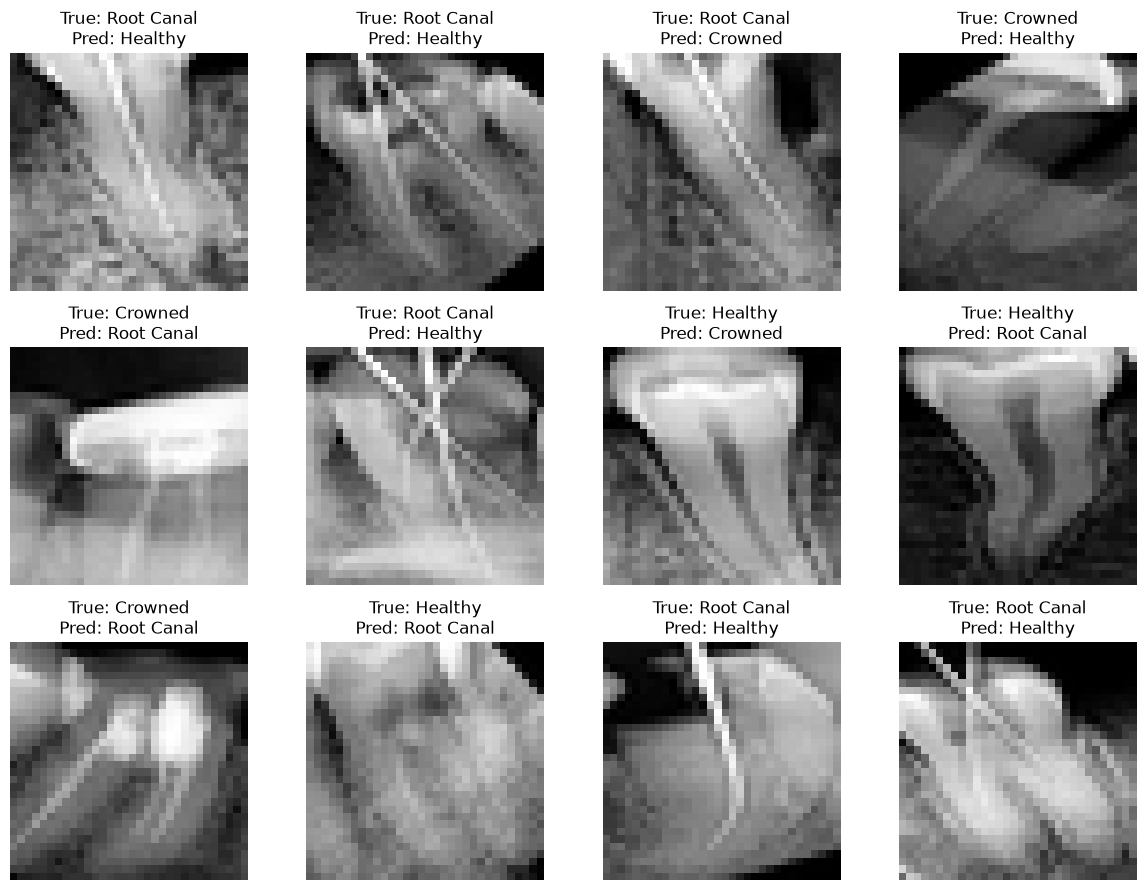

In [19]:
#show example images of incorrectly classified images with labels

wrong_indices = np.where(test_pred != y_test)[0]
print("num of images incorrectly classified:", len(wrong_indices))
number_to_show = min(12, len(wrong_indices))

plt.figure(figsize=(12, 9))
for plot_number, wrong_index in enumerate(wrong_indices[:number_to_show], start=1):
    plt.subplot(3, 4, plot_number)
    image = X_test[wrong_index].reshape(image_size, image_size)

    plt.imshow(image, cmap="gray")
    plt.title(f"True: {y_test[wrong_index]}\n" f"Pred: {test_pred[wrong_index]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#noticed some incorrect classifications are due to photo being both root canal and crown

In [20]:
def predict_new_xray(image_path):
    processed_image = preprocess_image(image_path)
    x_new = processed_image.reshape(1, -1)

    prediction = final_model.predict(x_new)[0]
    probabilities = final_model.predict_proba(x_new)[0]

    probability_table = pd.DataFrame({"Class": final_model.classes_,
        "Probability": probabilities}).sort_values("Probability", ascending=False)

    plt.figure(figsize=(4, 4))
    plt.imshow(processed_image, cmap="gray")
    plt.title(f"Prediction: {prediction}")
    plt.axis("off")
    plt.show()

    display(probability_table)

    return prediction

#example: predict_new_xray("new_xray.png")

In [21]:
model = {"model": final_model,
    "image_size": image_size,
    "classes": list(final_model.classes_)}

joblib.dump(model,directory / "dental_xray_logistic_regression.pkl")

print("model has been saved")

model has been saved


In [22]:
#find the baseline accuracies and f1 score
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)
dummy_pred = dummy_model.predict(X_valid)

print("Dummy validation accuracy:",accuracy_score(y_valid, dummy_pred))
print("Dummy validation balanced accuracy:",balanced_accuracy_score(y_valid, dummy_pred))
print("Dummy validation macro F1:",f1_score(y_valid, dummy_pred, average="macro"))

Dummy validation accuracy: 0.5107604017216643
Dummy validation balanced accuracy: 0.3333333333333333
Dummy validation macro F1: 0.22538778094333647


# Convolutional Neural Network (CNN)
Lorgistic regression model uses flattened set of values for each pixel, removing relative location information.
CNN is able to find shapes in images.
Below a CNN will be used with the same training, validation and test images so its performance can be compared.

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input,Conv2D,MaxPooling2D,Flatten,Dense,Dropout)
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.utils.class_weight import compute_class_weight
#set seeds to make reproducible results
np.random.seed(42)
tf.random.set_seed(42)

In [24]:
#use higher resolution as improves cnn
cnn_image_size = 64

#preprocess images again to 64x64, store in X_cnn_images
X_cnn_images = []
for image_path in df["fullPath"]:
    image = preprocess_image(image_path,image_size=cnn_image_size)
    X_cnn_images.append(image)

X_cnn_images = np.array(X_cnn_images)
print("CNN image shape:", X_cnn_images.shape)


CNN image shape: (4696, 64, 64)


In [25]:
#add colour channel, 1 as greyscael.
X_cnn_images = X_cnn_images[..., np.newaxis]
print("CNN image shape:", X_cnn_images.shape)

CNN image shape: (4696, 64, 64, 1)


In [26]:
#create train sets using same indicies
X_train_cnn = X_cnn_images[train_index]
X_temp_cnn = X_cnn_images[temp_index]

#divide temp dataset with same indicies
X_valid_cnn = X_temp_cnn[valid_relative_index]
X_test_cnn = X_temp_cnn[test_relative_index]

#check same dataset sizes
print("CNN training images:", len(X_train_cnn))
print("CNN validation images:", len(X_valid_cnn))
print("CNN test images:", len(X_test_cnn))

CNN training images: 3296
CNN validation images: 697
CNN test images: 703


In [27]:
#assign number to each classe
class_to_number = {
    "Healthy": 0,
    "Crowned": 1,
    "Root Canal": 2}

#create map so predictions canbe converted back
number_to_class = {
    0: "Healthy",
    1: "Crowned",
    2: "Root Canal"}

#convert labels from words to numbers
y_train_cnn = np.array([class_to_number[label] for label in y_train])
y_valid_cnn = np.array([class_to_number[label] for label in y_valid])
y_test_cnn = np.array([class_to_number[label]for label in y_test])

#show examples to check that the conversion worked correctly
print("Original labels:")
print(y_train[:10])
print("Numerical labels:")
print(y_train_cnn[:10])

Original labels:
['Root Canal' 'Crowned' 'Root Canal' 'Healthy' 'Crowned' 'Root Canal'
 'Healthy' 'Crowned' 'Root Canal' 'Root Canal']
Numerical labels:
[2 1 2 0 1 2 0 1 2 2]


In [28]:
#account for imbalance in amount of images per class
#done by having larger wieghts on classes with less images
class_numbers = np.unique(y_train_cnn)

weights = compute_class_weight(class_weight="balanced",classes=class_numbers,y=y_train_cnn)

#store weights in a dictionary
class_weights = dict(zip(class_numbers, weights))

print("class weights:")
print(class_weights)

class weights:
{np.int64(0): np.float64(1.0355010995915803), np.int64(1): np.float64(2.1250805931656997), np.int64(2): np.float64(0.6395032984090027)}


In [29]:
#create function so that CNN architecture can be createed easily
def create_cnn_model():
    model = Sequential([
        #define shape of xrays, 64x64x1
        Input(shape=(cnn_image_size, cnn_image_size, 1)),
        #first layer is 16 3x3 filters learn simple features
        Conv2D(filters=16,kernel_size=(3, 3),activation="relu"),
        #teduce the width and height of maps
        MaxPooling2D(pool_size=(2, 2)),
        #second layer learns complex features using features from first layer
        Conv2D(filters=32,kernel_size=(3, 3),activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        #third layer has 64 filters, more complex.
        Conv2D(filters=64,kernel_size=(3, 3),activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        #convert to one vector
        Flatten(),
        #connected layer combines features learned
        Dense(units=64,activation="relu"),
        #remove 30% of neurons to reduce overfitting
        Dropout(0.3),
        #final layer with softmax converts outputs to probabilities for each class
        Dense(units=3,activation="softmax")])
    return model

In [30]:
#define first CNN using create cnn function
cnn_model = create_cnn_model()

#display each layer, output shpe for each and params
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,011 (668.01 KB)

 Trainable params: 171,011 (668.01 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
cnn_model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
#stop training if model stops improving to avoid overfiiting 
early_stopping = EarlyStopping(monitor="val_loss",patience=4,restore_best_weights=True)

In [32]:
#Train CNN using only train set
history = cnn_model.fit(
    X_train_cnn,y_train_cnn,
    #max num of complete passes
    epochs=30,
    batch_size=32,
    #check model performance on validation xrays after each epoch
    validation_data=(X_valid_cnn,y_valid_cnn),
    class_weight=class_weights,
    #stop if no improvement
    callbacks=[early_stopping])

Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6647 - loss: 0.7422 - val_accuracy: 0.8752 - val_loss: 0.4153
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8495 - loss: 0.4288 - val_accuracy: 0.8852 - val_loss: 0.3311
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8802 - loss: 0.3363 - val_accuracy: 0.9154 - val_loss: 0.2365
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9120 - loss: 0.2712 - val_accuracy: 0.9340 - val_loss: 0.1996
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9211 - loss: 0.2375 - val_accuracy: 0.9168 - val_loss: 0.2369
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9278 - loss: 0.2085 - val_accuracy: 0.9168 - val_loss: 0.2328
Epoch 7/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9402 - loss: 0.1708 - val_accuracy: 0.9369 - val_loss: 0.1755
Epoch 8/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9436 - loss: 0.1491 - val_accuracy: 0.

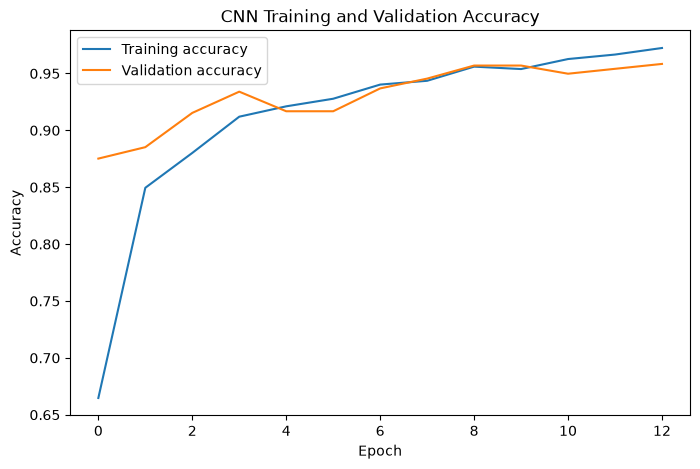

In [33]:
#plot the accuracy after each training epoch
plt.figure(figsize=(8, 5))
#accuracy on training xrays
plt.plot(history.history["accuracy"],label="Training accuracy")
#accuracy on validation xrays
plt.plot(history.history["val_accuracy"],label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.show()

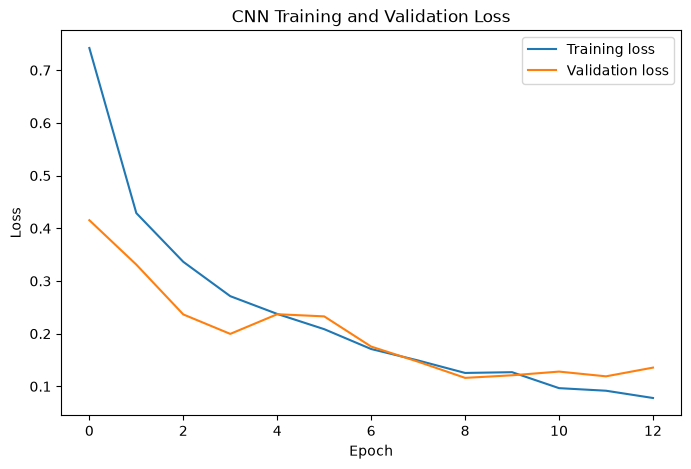

In [34]:
#plot training and validation loss after each epoch
plt.figure(figsize=(8, 5))
#training loss shows how much error remains on the training dataset
plt.plot(history.history["loss"],label="Training loss")
#validation loss shows how the model performs on validation dataset
plt.plot(history.history["val_loss"],label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.show()

In [35]:
#predict probability for each class for eachj validation xray
valid_probabilities = cnn_model.predict(X_valid_cnn)
#find class with the highest probability for each xray
valid_prediction_numbers = np.argmax(valid_probabilities,axis=1)
#convert numbers back to class names
valid_cnn_predictions = np.array([number_to_class[number]for number in valid_prediction_numbers])
#display the first predictions
print(valid_cnn_predictions[:10])

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
['Root Canal' 'Root Canal' 'Healthy' 'Crowned' 'Crowned' 'Healthy'
 'Root Canal' 'Crowned' 'Healthy' 'Root Canal']


In [36]:
#calc validation metrics
cnn_valid_accuracy = accuracy_score(y_valid,valid_cnn_predictions)
cnn_valid_balanced_accuracy = balanced_accuracy_score(y_valid,valid_cnn_predictions)
cnn_valid_macro_f1 = f1_score(y_valid,valid_cnn_predictions,average="macro")
print("CNN validation accuracy:", cnn_valid_accuracy)
print("CNN validation balanced accuracy:",cnn_valid_balanced_accuracy)
print("CNN validation macro F1:",cnn_valid_macro_f1)

CNN validation accuracy: 0.9569583931133429
CNN validation balanced accuracy: 0.9474039402763994
CNN validation macro F1: 0.9493701156813512


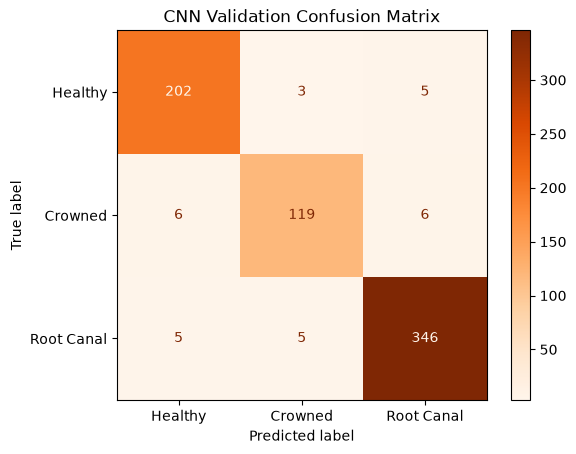

              precision    recall  f1-score   support

     Healthy      0.948     0.962     0.955       210
     Crowned      0.937     0.908     0.922       131
  Root Canal      0.969     0.972     0.971       356

    accuracy                          0.957       697
   macro avg      0.952     0.947     0.949       697
weighted avg      0.957     0.957     0.957       697



In [37]:
#show confustion matrix to see proportion of correct/incorrect prediciotns
ConfusionMatrixDisplay.from_predictions(y_valid,valid_cnn_predictions,labels=classesBeingUsed,cmap="Oranges")
plt.title("CNN Validation Confusion Matrix")
plt.show()
#print scores for each class
print(classification_report(y_valid,valid_cnn_predictions,labels=classesBeingUsed,digits=3))

In [38]:
#find epoch with lowest validation loss
best_epoch = np.argmin(history.history["val_loss"]) + 1
print("best number of epochs:", best_epoch)

best number of epochs: 9


In [39]:
#combine the original training and validation xrays
X_train_final_cnn = np.concatenate([X_train_cnn,X_valid_cnn])

#combine theri numerical labels
y_train_final_cnn = np.concatenate([y_train_cnn,y_valid_cnn])
print("Number of images used to train final CNN:",len(X_train_final_cnn))

Number of images used to train final CNN: 3993


In [40]:
#give class numbers for training set
final_class_numbers = np.unique(y_train_final_cnn)

#recalculate class weights 
final_weights = compute_class_weight(class_weight="balanced",classes=final_class_numbers,y=y_train_final_cnn)

#convert to  dictionary
final_class_weights = dict(zip(final_class_numbers,final_weights))
print("Final class weights:")
print(final_class_weights)

Final class weights:
{np.int64(0): np.float64(1.04720692368214), np.int64(1): np.float64(2.0540123456790123), np.int64(2): np.float64(0.6417550626808101)}


In [41]:
#make new CNN
final_cnn_model = create_cnn_model()
#compile with same settings
final_cnn_model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [42]:
#train new model
final_cnn_model.fit(X_train_final_cnn,y_train_final_cnn,
    #use best epochs from before as epochs
    epochs=best_epoch,
    batch_size=32,
    #use new class weights
    class_weight=final_class_weights)

Epoch 1/9
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6754 - loss: 0.7185    
Epoch 2/9
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8593 - loss: 0.3913 
Epoch 3/9
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8893 - loss: 0.3225 
Epoch 4/9
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9103 - loss: 0.2482 
Epoch 5/9
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9276 - loss: 0.2110 
Epoch 6/9
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9394 - loss: 0.1832 
Epoch 7/9
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9462 - loss: 0.1598 
Epoch 8/9
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9522 - loss: 0.1357
Epoch 9/9
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9604 - loss: 0.1210 


In [43]:
#predict probabilities for each xray in test set
test_probabilities_cnn = final_cnn_model.predict(X_test_cnn)

#select the predicted class for every image
test_prediction_numbers_cnn = np.argmax(test_probabilities_cnn,axis=1)

#convert nums back to the names
test_predictions_cnn = np.array([number_to_class[number]for number in test_prediction_numbers_cnn])

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [44]:
#calculate the final CNN accuracy
cnn_test_accuracy = accuracy_score(y_test,test_predictions_cnn)

#find balanced accuracy
cnn_test_balanced_accuracy = balanced_accuracy_score(y_test,test_predictions_cnn)

#find macro f1 using f1 for each class
cnn_test_macro_f1 = f1_score(y_test,test_predictions_cnn,average="macro")

print("CNN test accuracy:",cnn_test_accuracy)
print("CNN test balanced accuracy:",cnn_test_balanced_accuracy)
print("CNN test macro f1 score:",cnn_test_macro_f1)

CNN test accuracy: 0.9615931721194879
CNN test balanced accuracy: 0.9562149683827611
CNN test macro f1 score: 0.9551579304815258


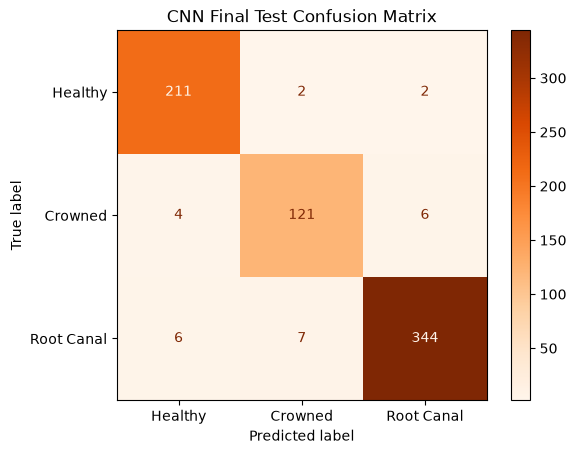

              precision    recall  f1-score   support

     Healthy      0.955     0.981     0.968       215
     Crowned      0.931     0.924     0.927       131
  Root Canal      0.977     0.964     0.970       357

    accuracy                          0.962       703
   macro avg      0.954     0.956     0.955       703
weighted avg      0.962     0.962     0.962       703



In [45]:
#show CNN confusion matrix using test labels
ConfusionMatrixDisplay.from_predictions(y_test,test_predictions_cnn,labels=classesBeingUsed,cmap="Oranges")
plt.title("CNN Final Test Confusion Matrix")
plt.show()
print(classification_report(y_test,test_predictions_cnn,labels=classesBeingUsed,digits=3))

# Compare Logistic Regression vs CNN models

In [46]:
#calculate logicstic regression accuracies
logistic_test_accuracy = accuracy_score(y_test,test_pred)
logistic_test_balanced_accuracy = balanced_accuracy_score(y_test,test_pred)
logistic_test_macro_f1 = f1_score(y_test,test_pred,average="macro")

#show table with both CNN and LR results
comparison = pd.DataFrame({
    "Model": ["Logistic Regression","CNN"],
    "Test Accuracy": [logistic_test_accuracy,cnn_test_accuracy],
    "Balanced Accuracy": [logistic_test_balanced_accuracy,cnn_test_balanced_accuracy],
    "Macro F1": [logistic_test_macro_f1,cnn_test_macro_f1]})
display(comparison)

,Model,Test Accuracy,Balanced Accuracy,Macro F1
0,Logistic Regression,0.709815,0.716421,0.702337
1,CNN,0.961593,0.956215,0.955158


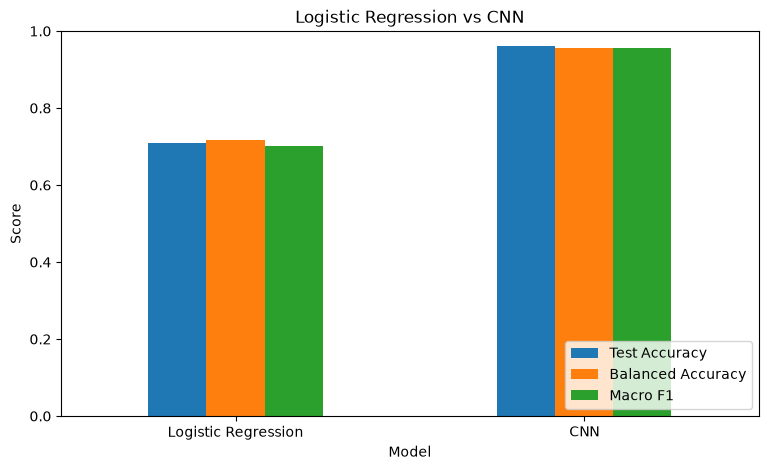

In [47]:
#make comparison graph
#use the model names index
comparison_plot = comparison.set_index("Model")

#plot all three metrics for both models
comparison_plot.plot(kind="bar",figsize=(9, 5))
plt.title("Logistic Regression vs CNN")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

Number of CNN images incorrectly classified: 27


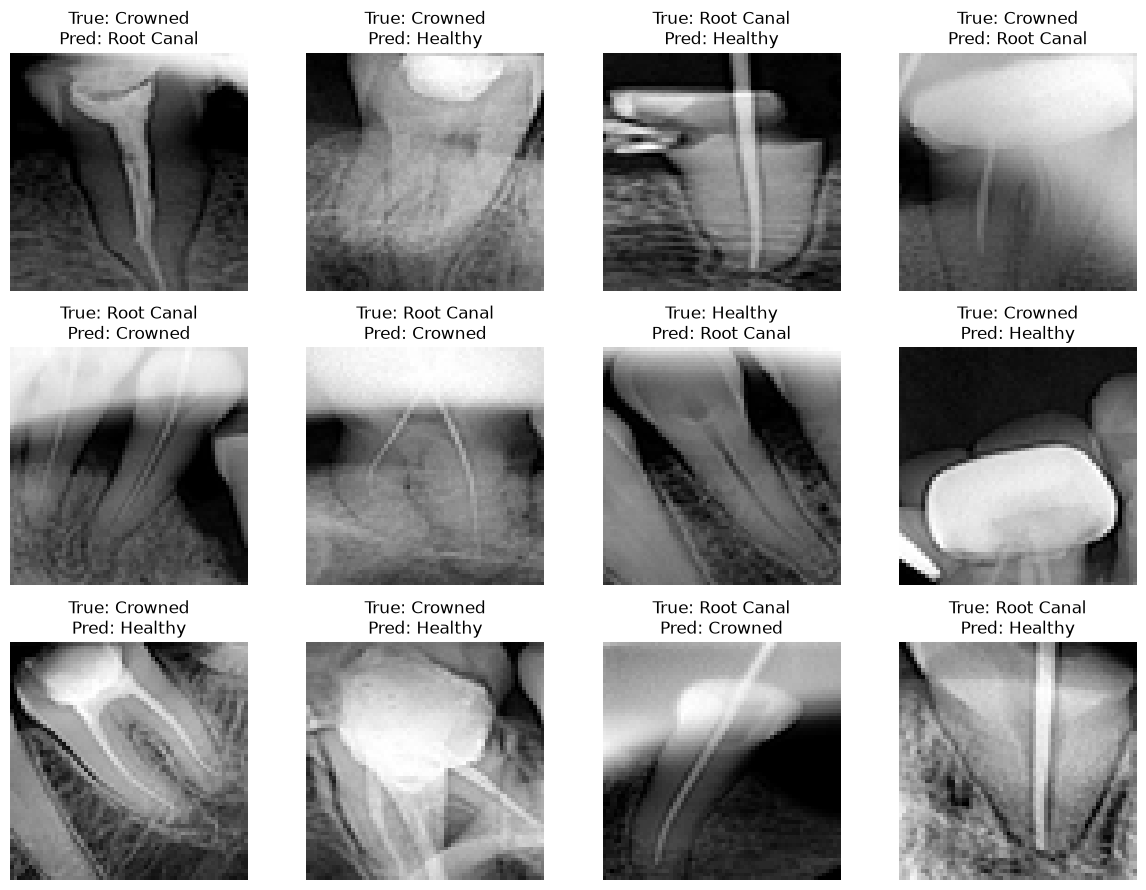

In [48]:
# Find the positions where the CNN prediction does not match the true class
cnn_wrong_indices = np.where(test_predictions_cnn != y_test)[0]

print("Number of CNN images incorrectly classified:",len(cnn_wrong_indices))

#decide max number to show, can change later
number_to_show = min(12,len(cnn_wrong_indices))

plt.figure(figsize=(12, 9))
for plot_number, wrong_index in enumerate(
    cnn_wrong_indices[:number_to_show],start=1):
    plt.subplot(3, 4, plot_number)
    #remove grayscale
    image = X_test_cnn[wrong_index].squeeze()
    plt.imshow(image,cmap="gray")
    #display correct label and incorrect prediction prediction
    plt.title(f"True: {y_test[wrong_index]}\n"f"Pred: {test_predictions_cnn[wrong_index]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## It can be seen in the incorrectly classified image examples shown abouve that some of the images in the dataset were actually labelled incorrectly so therefore the CNN classifier was actually correct for those images. 
## Some teeth also contained both root-canals and crowns but were only labelled as 1 or the other in the dataset, again causing incorrect classification.
## Also the quality/exposure/positioning of some of the xrays is poor which could be a cause for incorrect classification.

In [49]:
#save CNN model
final_cnn_model.save(directory / "dental_xray_cnn.keras")
print("CNN model saved")

CNN model saved


In [50]:
#save information for modle use
cnn_information = {
    "image_size": cnn_image_size,
    #save classes and corresponding numbers
    "classes": classesBeingUsed,
    "class_to_number": class_to_number,
    "number_to_class": number_to_class}
joblib.dump(cnn_information,directory / "cnn_information.pkl")
print("CNN info saved")

CNN info saved
